# Amazon product pricing anylsis
# Project Analysis by Pasha Mulenga- Business intelligence Analyst 

In [5]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [7]:
df = pd.read_csv("amazon.csv")

df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [13]:
# 3. Data Cleaning
import pandas as pd

# Clean 'actual_price' column
df['actual_price'] = (
    df['actual_price']
    .astype(str)  # ensure all values are strings
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
)
df['actual_price'] = pd.to_numeric(df['actual_price'], errors='coerce')  # invalid entries become NaN

# Clean 'discounted_price' column
df['discounted_price'] = (
    df['discounted_price']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
)
df['discounted_price'] = pd.to_numeric(df['discounted_price'], errors='coerce')

# Clean 'discount_percentage' column
df['discount_percentage'] = (
    df['discount_percentage']
    .astype(str)
    .str.replace('%', '', regex=False)
)
df['discount_percentage'] = pd.to_numeric(df['discount_percentage'], errors='coerce')

# Clean 'rating' column
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')  # non-numeric values become NaN

# Clean 'rating_count' column
df['rating_count'] = (
    df['rating_count']
    .astype(str)
    .str.replace(',', '', regex=False)
)
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce').fillna(0)

In [15]:
# 4. Feature Engineering
df['price_difference'] = df['actual_price'] - df['discounted_price']

df['engagement_score'] = df['rating'] * df['rating_count']

In [17]:
# Price segmentation
df['price_segment'] = pd.qcut(
    df['actual_price'],
    q=4,
    labels=["Low","Medium","High","Premium"]
)

In [19]:
# 5. SQL Database
conn = sqlite3.connect("amazon_analysis.db")

df.to_sql(
    "amazon_products",
    conn,
    if_exists="replace",
    index=False
)

1465

In [21]:
# 6. SQL analysis queries 

# Category Performance
query = """
SELECT
category,
COUNT(*) AS product_count,
AVG(rating) AS avg_rating,
AVG(discount_percentage) AS avg_discount
FROM amazon_products
GROUP BY category
ORDER BY avg_rating DESC
"""

category_performance = pd.read_sql(query, conn)
category_performance.head()

,category,product_count,avg_rating,avg_discount
0,Computers&Accessories|Tablets,1,4.6,29.0
1,OfficeProducts|OfficeElectronics|Calculators|B...,1,4.5,0.0
2,HomeImprovement|Electrical|CordManagement,1,4.5,58.0
3,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,1,4.5,8.0
4,"Home&Kitchen|Kitchen&HomeAppliances|Coffee,Tea...",1,4.5,27.0


In [23]:
# Most Reviewed Products
query = """
SELECT
product_name,
rating,
rating_count
FROM amazon_products
ORDER BY rating_count DESC
LIMIT 10
"""

top_reviewed = pd.read_sql(query, conn)
top_reviewed

,product_name,rating,rating_count
0,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426973.0
1,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",4.4,426973.0
2,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",4.4,426973.0
3,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426972.0
4,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0
5,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0
6,boAt BassHeads 100 in-Ear Wired Headphones wit...,4.1,363711.0
7,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",4.1,313836.0
8,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",4.1,313836.0
9,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...",4.1,313832.0


In [25]:
# Largest Price Reductions
query = """
SELECT
product_name,
actual_price,
discounted_price,
(actual_price - discounted_price) AS price_drop
FROM amazon_products
ORDER BY price_drop DESC
LIMIT 10
"""

largest_discounts = pd.read_sql(query, conn)
largest_discounts

,product_name,actual_price,discounted_price,price_drop
0,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,139900.0,77990.0,61910.0
1,"Coway Professional Air Purifier for Home, Long...",59900.0,14400.0,45500.0
2,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",74999.0,37990.0,37009.0
3,VU 138 cm (55 inches) Premium Series 4K Ultra ...,65000.0,29990.0,35010.0
4,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,75990.0,42990.0,33000.0
5,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,79990.0,47990.0,32000.0
6,ECOVACS DEEBOT N8 2-in-1 Robotic Vacuum Cleane...,59900.0,27900.0,32000.0
7,VU 164 cm (65 inches) The GloLED Series 4K Sma...,85000.0,54990.0,30010.0
8,VU 139 cm (55 inches) The GloLED Series 4K Sma...,65000.0,37999.0,27001.0
9,TCL 108 cm (43 inches) 4K Ultra HD Certified A...,51990.0,24990.0,27000.0


In [27]:
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

In [29]:
df["discount_percentage"] = pd.to_numeric(df["discount_percentage"], errors="coerce")

In [ ]:
df["rating_count"] = pd.to_numeric(df["rating_count"], errors="coerce")

In [ ]:
df = df.dropna(subset=["rating"])

In [31]:
# 7. Category Analysis
category_analysis = df.groupby("category").agg({
    "rating":"mean",
    "rating_count":"sum",
    "discount_percentage":"mean"
}).sort_values(by="rating", ascending=False)

category_analysis.head()

,rating,rating_count,discount_percentage
category,,,
Computers&Accessories|Tablets,4.6,2886.0,29.0
Computers&Accessories|NetworkingDevices|NetworkAdapters|PowerLANAdapters,4.5,22420.0,40.0
Electronics|Cameras&Photography|Accessories|Film,4.5,4875.0,0.0
Electronics|HomeAudio|MediaStreamingDevices|StreamingClients,4.5,224.0,0.0
OfficeProducts|OfficeElectronics|Calculators|Basic,4.5,8610.0,0.0


In [39]:
# 8. Correlation Analysis: this supports the pricing vs rating insight.
correlation_matrix = df[[
    "actual_price",
    "discount_percentage",
    "rating",
    "rating_count"
]].corr()

correlation_matrix

,actual_price,discount_percentage,rating,rating_count
actual_price,1.000000,-0.118098,0.121642,-0.035890
discount_percentage,-0.118098,1.000000,-0.155375,0.010868
rating,0.121642,-0.155375,1.000000,0.101584
rating_count,-0.035890,0.010868,0.101584,1.000000


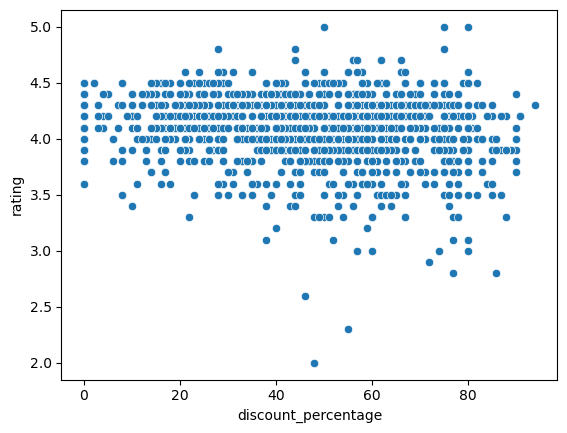

In [37]:
# 9. isualization: Discount vs Rating :HTML report charts.

# Title:Discount Percentage vs Product Rating

plt.figure()

sns.scatterplot(
    data=df,
    x="discount_percentage",
    y="rating"
)

plt.show()

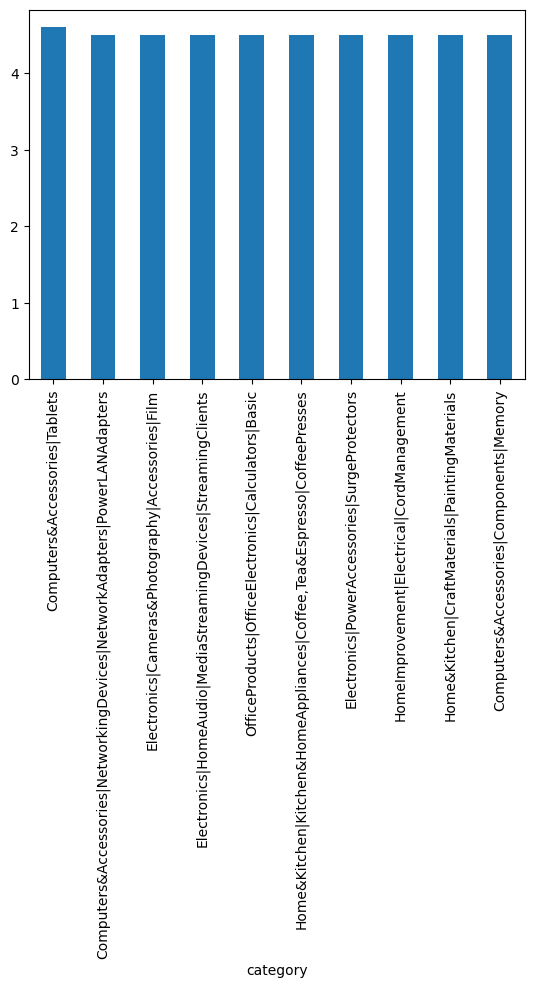

In [41]:
# 10. Category Rating Visualization

# Title:Top Categories by Average Rating
top_categories = (
    df.groupby("category")["rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_categories.plot(kind="bar")

plt.show()

In [55]:
df["price_segment"] = pd.qcut(
    df["actual_price"],
    q=4,
    labels=["Low", "Medium", "High", "Premium"]
)

In [68]:
# 11. Price Tier Analysis
price_segment_analysis = df.groupby("price_segment", observed=True)["rating"].mean()

price_segment_analysis

price_segment
Low        4.091576
Medium     4.089863
High       4.081370
Premium    4.123497
Name: rating, dtype: float64

In [57]:
model_df = df[[
    "actual_price",
    "discount_percentage",
    "rating_count",
    "rating"
]].dropna()

In [66]:
# 12. Predictive Model (Rating Estimation) :Predictive Modeling section of your report.
X = model_df[[
    "actual_price",
    "discount_percentage",
    "rating_count"
]]

y = model_df["rating"]

# Train test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Train model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

# Model Performance 
from sklearn.metrics import r2_score, root_mean_squared_error

r2 = r2_score(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: 0.04764341211404832
RMSE: 0.27184465523214957


In [63]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,actual_price,2.981021e-06
1,discount_percentage,-1.915283e-03
2,rating_count,7.439883e-07
